In [67]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})

from utils import phase_velocity_vti
from squirt_flow import squirt_flow_drained,squirt_flow_undrained
from EMT import hudson,dem

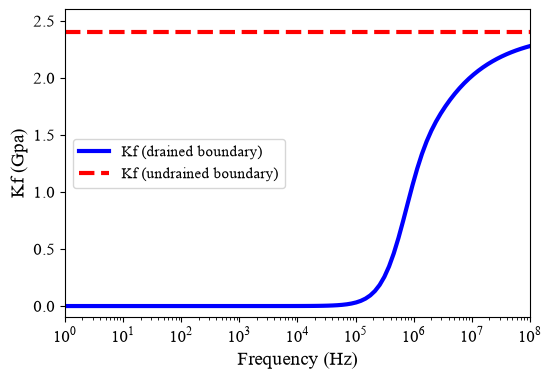

In [68]:
Km    = 10e9
Gm    = 8e9
rhom  = 2.3e3 
Kf    = 2.4e9
Gf    = 0
vis   = 1e-3
h0    = 1e-7
asp   = 1e-3
rb    = h0/(2*asp)
f     = np.logspace(0,8,100)
epsilon = 0.05


Kf_drained   = squirt_flow_drained(Kf,vis,h0,rb,f)
Kf_undrained = squirt_flow_undrained(Kf,f)

plt.figure(figsize=(6,4))
plt.semilogx(f,np.real(Kf_drained)/1e9,
             label='Kf (drained boundary)',color='blue',linewidth=3)
plt.semilogx(f,Kf_undrained/1e9,
             label='Kf (undrained boundary)',color='red',linestyle='--',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Kf (Gpa)')
plt.xlim(f.min(),f.max())
plt.ylim(-0.1,2.6)
plt.legend()
plt.show()

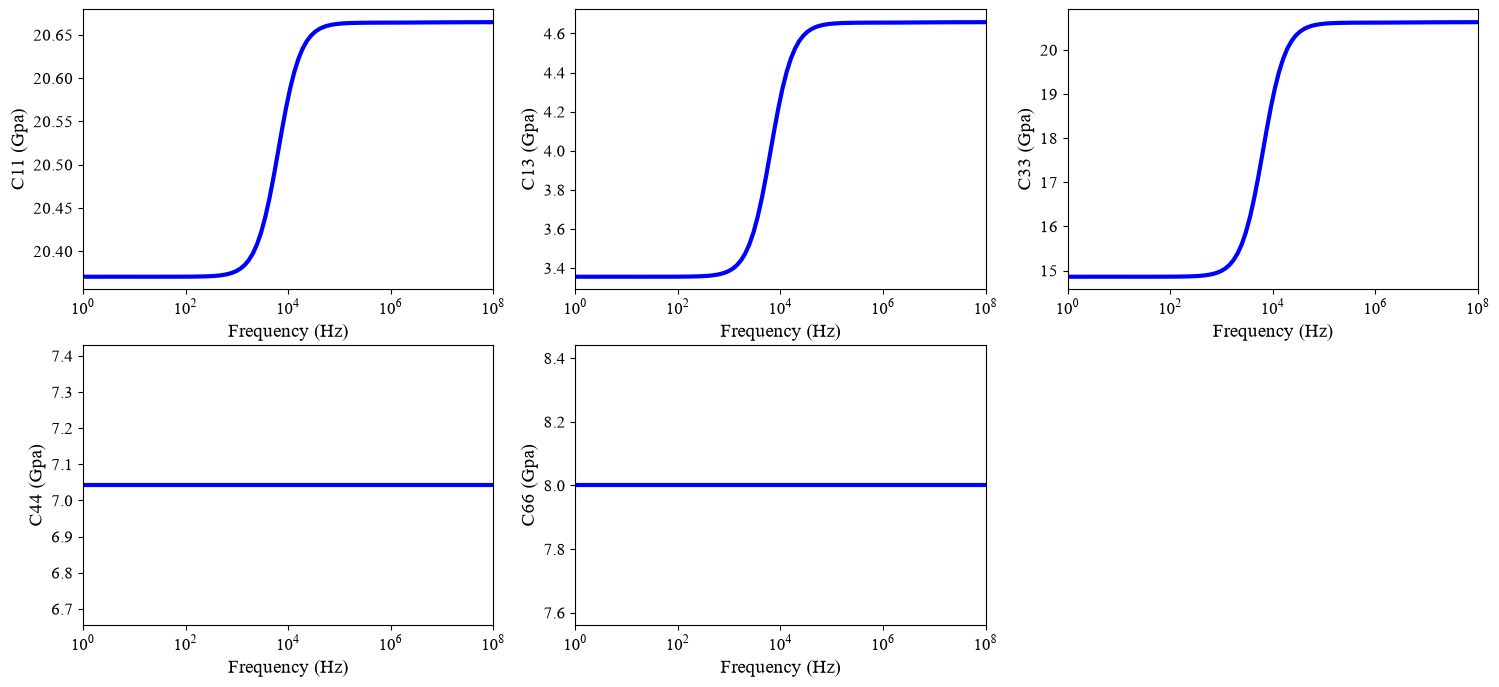

In [69]:
C1_aniso = np.zeros((5,len(f)),dtype=np.complex128) 
C11      = np.zeros(len(f),dtype=np.complex128) 
C13      = np.zeros(len(f),dtype=np.complex128) 
C33      = np.zeros(len(f),dtype=np.complex128) 
C44      = np.zeros(len(f),dtype=np.complex128) 
C66      = np.zeros(len(f),dtype=np.complex128) 
for i in range(len(f)):
    C1_aniso[:,i] = hudson(Km,Gm,Kf_drained[i],Gf,asp,epsilon)[0]
    C11[i] = C1_aniso[0,i]
    C13[i] = C1_aniso[1,i]
    C33[i] = C1_aniso[2,i]
    C44[i] = C1_aniso[3,i]
    C66[i] = C1_aniso[4,i]

plt.figure(figsize=(18,8))
plt.subplot(2,3,1)
plt.semilogx(f,np.real(C11)/1e9,
             label='C11',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C11 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,2)
plt.semilogx(f,np.real(C13)/1e9,
             label='C13',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C13 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,3)
plt.semilogx(f,np.real(C33)/1e9,
             label='C33',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C33 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,4)
plt.semilogx(f,np.real(C44)/1e9,
             label='C44',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C44 (Gpa)')
plt.xlim(f.min(),f.max())

plt.subplot(2,3,5)
plt.semilogx(f,np.real(C66)/1e9,
             label='C66',color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('C66 (Gpa)')
plt.xlim(f.min(),f.max())

plt.show()

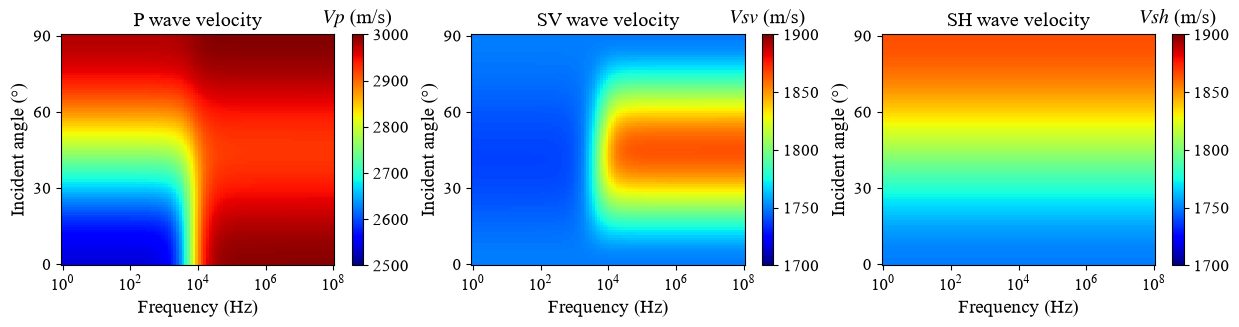

In [88]:
theta = np.arange(0,91) * np.pi / 180
deg   = np.arange(0,91)

Vp  = np.zeros((len(theta),len(f)),dtype=np.complex128)
Vsv = np.zeros((len(theta),len(f)),dtype=np.complex128)
Vsh = np.zeros((len(theta),len(f)),dtype=np.complex128)
for i in range(len(f)):
    Vp[:,i],Vsv[:,i],Vsh[:,i] = phase_velocity_vti(C11[i],C13[i],C33[i],C44[i],C66[i],theta,rhom)

plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
im = plt.pcolormesh(
    f,
    deg,
    np.real(Vp),
    shading='auto',
    cmap='jet',
    vmin=2500,
    vmax=3000
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Vp$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])
plt.title('P wave velocity')

plt.subplot(1,3,2)
im = plt.pcolormesh(
    f,
    deg,
    np.real(Vsv),
    shading='auto',
    cmap='jet',
    vmin=1700,
    vmax=1900
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Vsv$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])
plt.title('SV wave velocity')

plt.subplot(1,3,3)
im = plt.pcolormesh(
    f,
    deg,
    np.real(Vsh),
    shading='auto',
    cmap='jet',
    vmin=1700,
    vmax=1900
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Vsh$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])
plt.title('SH wave velocity')
plt.show()

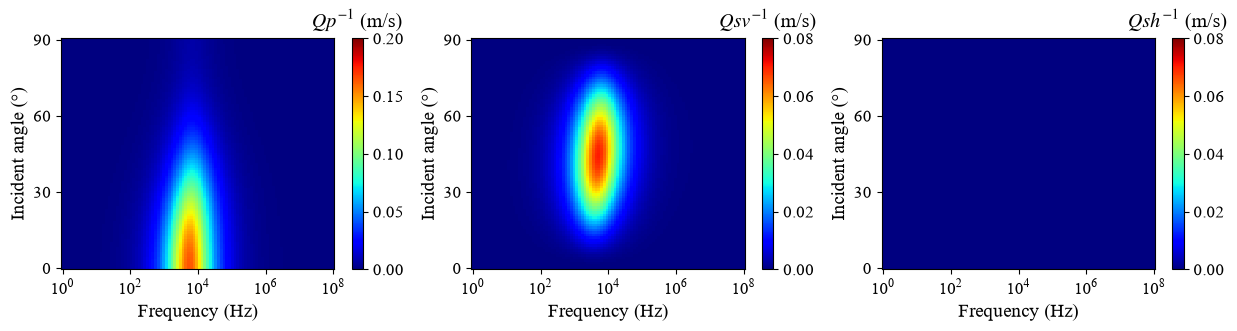

In [96]:
plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
im = plt.pcolormesh(
    f,
    deg,
    np.imag(Vp**2)/np.real(Vp**2),
    shading='auto',
    cmap='jet',
    vmin=0,
    vmax=0.2
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Qp^{-1}$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])

plt.subplot(1,3,2)
im = plt.pcolormesh(
    f,
    deg,
    np.imag(Vsv**2)/np.real(Vsv**2),
    shading='auto',
    cmap='jet',
    vmin=0,
    vmax=0.08
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Qsv^{-1}$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])

plt.subplot(1,3,3)
im = plt.pcolormesh(
    f,
    deg,
    np.imag(Vsh**2)/np.real(Vsh**2),
    shading='auto',
    cmap='jet',
    vmin=0,
    vmax=0.08
)
cbar = plt.colorbar(im)
cbar.ax.set_title(r'$Qsh^{-1}$ (m/s)',pad=8)
plt.xlabel('Frequency (Hz)')
plt.xscale('log')
plt.ylabel('Incident angle (°)')
plt.yticks([0,30,60,90])

plt.show()